# Análise Exploratória e Previsão da Demanda de Produção das Lojas do Bolos do Flávio

### Projeto Final — Disciplina *Novas Tecnologias*
**Curso:** Ciência da Computação — Universidade Católica de Brasília (UCB)

---

Este notebook aplica técnicas de Ciência de Dados a um problema **real** de negócio: o planejamento da produção de bolos da rede *Bolos do Flávio*, em Brasília. Utiliza exclusivamente as tecnologias vistas em sala — **Python, Pandas, NumPy, Matplotlib e Scikit-Learn**.

## 1. Introdução

A **Bolos do Flávio** é uma rede de lojas de bolos com unidades distribuídas pela região de Brasília. A produção dos bolos é centralizada em uma fábrica e distribuída às lojas, o que torna o **planejamento da produção** uma atividade crítica: produzir além da demanda gera perda (bolo é perecível); produzir aquém gera ruptura de estoque e venda perdida.

Neste trabalho utilizamos dois conjuntos de dados reais referentes ao mês de **abril de 2026**:

- **Base de Produção** — registra, para cada **sabor**, **loja** e **dia**, a quantidade produzida/distribuída. É a base central deste estudo.
- **Base de Faturamento** — registra o fechamento financeiro diário de cada loja (vendas por canal e faturamento bruto/líquido).

O problema de negócio que motiva o projeto é: **dado um sabor, uma loja e um dia da semana, qual a quantidade esperada de produção?** Responder isso ajuda o setor de Planejamento e Controle de Produção (PCP) a dimensionar a fábrica.

## 2. Objetivos

**Objetivo geral:** demonstrar a aplicação de um fluxo completo de Ciência de Dados (da limpeza ao modelo) sobre dados reais da empresa.

**Objetivos específicos:**

1. Importar, limpar e preparar as duas bases de dados.
2. Realizar análise exploratória e gerar estatísticas descritivas.
3. Construir visualizações com Matplotlib para entender padrões de produção.
4. Integrar produção e faturamento para investigar a relação entre volume produzido e receita.
5. Desenvolver um modelo de **regressão (Random Forest Regressor)** para estimar a quantidade de produção por sabor, loja e dia da semana.
6. Avaliar o modelo com métricas apropriadas e compará-lo a um *baseline* simples.

## 3. Importação das bibliotecas

Carregamos apenas as bibliotecas vistas na disciplina. O *Scikit-Learn* é importado em módulos específicos, conforme a necessidade de cada etapa do modelo.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Configurações gerais de exibição e de gráficos
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print('Bibliotecas importadas com sucesso.')

Bibliotecas importadas com sucesso.


## 4. Leitura dos dados

As duas bases vêm de origens diferentes e, por isso, têm **formatos de arquivo distintos** — um detalhe importante que precisa ser tratado já na leitura:

- A base de **produção** usa vírgula (`,`) como separador de colunas e ponto como decimal.
- A base de **faturamento** (já tratada anteriormente, exportada do ERP Teknisa) usa ponto e vírgula (`;`) como separador e **vírgula como separador decimal** — padrão pt-BR.

Lemos `QUANTIDADE` como texto de propósito: existem alguns valores fracionados (ex.: `0,5`) que serão convertidos de forma controlada na etapa de limpeza.

In [2]:
# Base de Produção (separador vírgula)
prod = pd.read_csv('ProduçãoBolos_Lojas_Abril2026.csv', sep=',', dtype={'QUANTIDADE': str})

# Base de Faturamento (separador ';' e decimal ',')
fat = pd.read_csv('Faturamento_Lojas_Abril2026.csv', sep=';', decimal=',')

print('Produção  :', prod.shape[0], 'linhas x', prod.shape[1], 'colunas')
print('Faturamento:', fat.shape[0], 'linhas x', fat.shape[1], 'colunas')

Produção  : 46345 linhas x 5 colunas
Faturamento: 720 linhas x 9 colunas


### 4.1. Primeira inspeção — Base de Produção

In [3]:
prod.head()

,SABOR,UNIDADE,QUANTIDADE,DATA,DIA DA SEMANA
0,MESCLADO,QUADRA 1,5,01/04/2026,quarta-feira
1,MESCLADO,CENTRAL,8,01/04/2026,quarta-feira
2,MESCLADO,NOROESTE,8,01/04/2026,quarta-feira
3,MESCLADO,ASA SUL,10,01/04/2026,quarta-feira
4,MESCLADO,ASA NORTE,8,01/04/2026,quarta-feira


In [4]:
prod.info()

<class 'pandas.DataFrame'>
RangeIndex: 46345 entries, 0 to 46344
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   SABOR          46345 non-null  str  
 1   UNIDADE        46345 non-null  str  
 2   QUANTIDADE     46345 non-null  str  
 3   DATA           46345 non-null  str  
 4   DIA DA SEMANA  46345 non-null  str  
dtypes: str(5)
memory usage: 1.8 MB


### 4.2. Primeira inspeção — Base de Faturamento

In [5]:
fat.head()

,LOJA,DATA,DIA DA SEMANA,VENDAS DELIVERY BRUTO,VENDAS DELIVERY LIQUIDO,VENDAS BALCAO BRUTO,VENDAS BALCAO LIQUIDO,FATURAMENTO BRUTO,FATURAMENTO LIQUIDO
0,0001 - BOLOS DO FLAVIO - ASA SUL,01/04/2026,Quarta-feira,4126.9,3743.35,14451.7,14429.7,18578.6,18173.05
1,0001 - BOLOS DO FLAVIO - ASA SUL,02/04/2026,Quinta-feira,4497.5,4065.63,18804.8,18787.0,23302.3,22852.63
2,0001 - BOLOS DO FLAVIO - ASA SUL,03/04/2026,Sexta-feira,767.9,697.07,8870.7,8870.7,9638.6,9567.77
3,0001 - BOLOS DO FLAVIO - ASA SUL,04/04/2026,Sábado,5732.7,5127.36,14563.8,14563.8,20296.5,19691.16
4,0001 - BOLOS DO FLAVIO - ASA SUL,05/04/2026,Domingo,0.0,0.00,7803.4,7803.4,7803.4,7803.40


In [6]:
fat.info()

<class 'pandas.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   LOJA                     720 non-null    str    
 1   DATA                     720 non-null    str    
 2   DIA DA SEMANA            720 non-null    str    
 3   VENDAS DELIVERY BRUTO    720 non-null    float64
 4   VENDAS DELIVERY LIQUIDO  720 non-null    float64
 5   VENDAS BALCAO BRUTO      720 non-null    float64
 6   VENDAS BALCAO LIQUIDO    720 non-null    float64
 7   FATURAMENTO BRUTO        720 non-null    float64
 8   FATURAMENTO LIQUIDO      720 non-null    float64
dtypes: float64(6), str(3)
memory usage: 50.8 KB


**Leitura inicial:** ambas as bases foram carregadas sem perda de linhas. A base de produção tem ~46 mil registros (granularidade sabor × loja × dia) e a de faturamento tem 720 (granularidade loja × dia). Note que `QUANTIDADE` ainda está como texto (`object`) e as datas como texto — isso será corrigido na próxima seção.

## 5. Limpeza e preparação dos dados

Esta é a etapa mais importante para garantir a qualidade da análise. A partir da inspeção inicial, identificamos pontos que precisam de tratamento e tomamos as seguintes decisões, todas documentadas:

| Situação encontrada | Decisão | Justificativa |
|---|---|---|
| `QUANTIDADE` como texto, com alguns valores fracionados (`0,5`) | Converter para número trocando `,` por `.` | São quantidades reais (meia unidade), não erros |
| 18 quantidades **negativas** (−1 a −5) | Ajustar para **0** | Representam ajustes/devoluções; não existe "produzir quantidade negativa" |
| ~24 mil quantidades **iguais a 0** | **Manter** | São informação válida: aquele sabor não foi produzido para aquela loja naquele dia |
| Nomes de loja **divergentes** entre as bases | Criar chave comum `COD_LOJA` | Produção usa nome curto; faturamento usa "código - nome" |
| Loja **SIA (0024)**: 1 só dia de faturamento, sem produção | **Remover** | Sem representatividade para análise mensal |
| Loja **LOJINHA** = **LOJA FABRICA (0014)** | Unificar pelo código `0014` | É a mesma loja com nomes diferentes em cada base |

As datas (texto `dd/mm/aaaa`) também são convertidas para o tipo `datetime`.

### 5.1. Tratamento da coluna QUANTIDADE (base de produção)

In [7]:
# Converte texto para número (alguns valores usam vírgula decimal, ex.: '0,5')
prod['QUANTIDADE'] = pd.to_numeric(
    prod['QUANTIDADE'].str.replace(',', '.', regex=False), errors='coerce'
)
print('Valores que não puderam ser convertidos:', prod['QUANTIDADE'].isna().sum())

# Quantidades negativas (ajustes/devoluções) -> 0, preservando a linha
qtd_negativas = int((prod['QUANTIDADE'] < 0).sum())
prod['QUANTIDADE'] = prod['QUANTIDADE'].clip(lower=0)

print(f'Quantidades negativas ajustadas para 0 : {qtd_negativas}')
print(f'Quantidades iguais a 0 (mantidas)      : {int((prod["QUANTIDADE"] == 0).sum())}')
print(f'Quantidades fracionadas (0 < q < 1)    : {int(((prod["QUANTIDADE"] > 0) & (prod["QUANTIDADE"] < 1)).sum())}')

Valores que não puderam ser convertidos: 0
Quantidades negativas ajustadas para 0 : 18
Quantidades iguais a 0 (mantidas)      : 24173
Quantidades fracionadas (0 < q < 1)    : 2


### 5.2. Conversão de datas e padronização de textos

In [8]:
# Datas -> datetime
prod['DATA'] = pd.to_datetime(prod['DATA'], format='%d/%m/%Y')
fat['DATA']  = pd.to_datetime(fat['DATA'],  format='%d/%m/%Y')

# Remove espaços extras (inclusive duplos) em colunas de texto da produção
for col in ['SABOR', 'UNIDADE', 'DIA DA SEMANA']:
    prod[col] = prod[col].str.strip().str.replace(r'\s+', ' ', regex=True)

# Dia da semana como categoria ORDENADA (melhora ordenação em tabelas e gráficos)
ordem_dias = ['segunda-feira', 'terça-feira', 'quarta-feira', 'quinta-feira',
              'sexta-feira', 'sábado', 'domingo']
prod['DIA DA SEMANA'] = pd.Categorical(prod['DIA DA SEMANA'], categories=ordem_dias, ordered=True)

print('Período da produção  :', prod['DATA'].min().date(), '->', prod['DATA'].max().date())
print('Período do faturamento:', fat['DATA'].min().date(), '->', fat['DATA'].max().date())

Período da produção  : 2026-04-01 -> 2026-04-30
Período do faturamento: 2026-04-01 -> 2026-04-30


### 5.3. Padronização dos nomes de loja (chave comum)

Para conseguir integrar as duas bases mais adiante, criamos uma chave única por loja: o código `COD_LOJA`. O dicionário abaixo traduz o nome curto da base de produção para o código oficial usado no faturamento. Em seguida, um segundo dicionário fornece um **nome limpo** por código, usado nas visualizações.

In [9]:
# De-para: nome na base de produção -> código oficial da loja
mapa_producao_para_codigo = {
    'ASA SUL':'0001','POSTO':'0002','GUARA':'0003','BAHAMAS':'0004','QUADRA 1':'0005',
    'NOROESTE':'0006','ASA NORTE':'0007','CENTRAL':'0008','GILBERTO':'0009','JARDIM':'0010',
    'CONTAINER':'0011','LOJINHA':'0014','EPNB':'0016','GAMA':'0017','SAMAMBAIA':'0018',
    'ARNIQUEIRA':'0019','CONJ. NACIONAL':'0020','RECANTO':'0021','PONTE ALTA':'0022',
    'SAMAMBAIA SUL':'0023','TAGUATINGA':'1001','SUDOESTE 1':'1002','SUDOESTE 2':'1003',
    'VICENTE PIRES':'1004','CEILANDIA':'1005','ALAMEDA':'1006'
}

# Nome limpo por código (para exibição)
codigo_para_nome = {
    '0001':'ASA SUL','0002':'POSTO','0003':'GUARA','0004':'BAHAMAS','0005':'QUADRA 1',
    '0006':'NOROESTE','0007':'ASA NORTE','0008':'CENTRAL','0009':'GILBERTO','0010':'JARDIM BOTANICO',
    '0011':'CONTAINER','0014':'LOJA FABRICA','0016':'EPNB','0017':'GAMA','0018':'SAMAMBAIA',
    '0019':'ARNIQUEIRAS','0020':'CONJ NACIONAL','0021':'RECANTO','0022':'PONTE ALTA','0023':'SAMAMBAIA SUL',
    '0024':'SIA','1001':'TAGUATINGA','1002':'SUDOESTE 1','1003':'SUDOESTE 2','1004':'VICENTE PIRES',
    '1005':'CEILANDIA','1006':'TAGSUL ALAMEDA'
}

# Aplica na produção
prod['COD_LOJA'] = prod['UNIDADE'].map(mapa_producao_para_codigo)
prod['LOJA'] = prod['COD_LOJA'].map(codigo_para_nome)

# Aplica no faturamento (o código são os 4 primeiros caracteres do rótulo)
fat['COD_LOJA'] = fat['LOJA'].str[:4]
fat['LOJA_NOME'] = fat['COD_LOJA'].map(codigo_para_nome)

print('Unidades de produção sem correspondência:', int(prod['COD_LOJA'].isna().sum()))
print('Lojas distintas na produção:', prod['COD_LOJA'].nunique())

Unidades de produção sem correspondência: 0
Lojas distintas na produção: 26


### 5.4. Remoção da loja SIA (sem representatividade)

In [10]:
registros_sia = int((fat['COD_LOJA'] == '0024').sum())
fat = fat[fat['COD_LOJA'] != '0024'].copy()
print(f'Registros da SIA removidos do faturamento: {registros_sia}')
print('Lojas no faturamento após a limpeza:', fat['COD_LOJA'].nunique())

Registros da SIA removidos do faturamento: 1
Lojas no faturamento após a limpeza: 26


### 5.5. Verificação final da limpeza

Conferimos os tipos de dados e a ausência de nulos nas duas bases já tratadas.

In [11]:
print('=========== BASE DE PRODUÇÃO ===========')
print(prod.dtypes)
print('\nNulos por coluna:')
print(prod.isna().sum())
print('\n=========== BASE DE FATURAMENTO ===========')
print(fat.dtypes)
print('\nNulos por coluna:')
print(fat.isna().sum())

=========== BASE DE PRODUÇÃO ===========
SABOR                       str
UNIDADE                     str
QUANTIDADE              float64
DATA             datetime64[us]
DIA DA SEMANA          category
COD_LOJA                    str
LOJA                        str
dtype: object

Nulos por coluna:
SABOR            0
UNIDADE          0
QUANTIDADE       0
DATA             0
DIA DA SEMANA    0
COD_LOJA         0
LOJA             0
dtype: int64

=========== BASE DE FATURAMENTO ===========
LOJA                                  str
DATA                       datetime64[us]
DIA DA SEMANA                         str
VENDAS DELIVERY BRUTO             float64
VENDAS DELIVERY LIQUIDO           float64
VENDAS BALCAO BRUTO               float64
VENDAS BALCAO LIQUIDO             float64
FATURAMENTO BRUTO                 float64
FATURAMENTO LIQUIDO               float64
COD_LOJA                              str
LOJA_NOME                             str
dtype: object

Nulos por coluna:
LOJA            

In [12]:
# Prévia das bases limpas
print('Produção (amostra):')
display(prod.head())
print('Faturamento (amostra):')
display(fat.head())

Produção (amostra):


,SABOR,UNIDADE,QUANTIDADE,DATA,DIA DA SEMANA,COD_LOJA,LOJA
0,MESCLADO,QUADRA 1,5.0,2026-04-01,quarta-feira,0005,QUADRA 1
1,MESCLADO,CENTRAL,8.0,2026-04-01,quarta-feira,0008,CENTRAL
2,MESCLADO,NOROESTE,8.0,2026-04-01,quarta-feira,0006,NOROESTE
3,MESCLADO,ASA SUL,10.0,2026-04-01,quarta-feira,0001,ASA SUL
4,MESCLADO,ASA NORTE,8.0,2026-04-01,quarta-feira,0007,ASA NORTE


Faturamento (amostra):


,LOJA,DATA,DIA DA SEMANA,VENDAS DELIVERY BRUTO,VENDAS DELIVERY LIQUIDO,VENDAS BALCAO BRUTO,VENDAS BALCAO LIQUIDO,FATURAMENTO BRUTO,FATURAMENTO LIQUIDO,COD_LOJA,LOJA_NOME
0,0001 - BOLOS DO FLAVIO - ASA SUL,2026-04-01,Quarta-feira,4126.9,3743.35,14451.7,14429.7,18578.6,18173.05,0001,ASA SUL
1,0001 - BOLOS DO FLAVIO - ASA SUL,2026-04-02,Quinta-feira,4497.5,4065.63,18804.8,18787.0,23302.3,22852.63,0001,ASA SUL
2,0001 - BOLOS DO FLAVIO - ASA SUL,2026-04-03,Sexta-feira,767.9,697.07,8870.7,8870.7,9638.6,9567.77,0001,ASA SUL
3,0001 - BOLOS DO FLAVIO - ASA SUL,2026-04-04,Sábado,5732.7,5127.36,14563.8,14563.8,20296.5,19691.16,0001,ASA SUL
4,0001 - BOLOS DO FLAVIO - ASA SUL,2026-04-05,Domingo,0.0,0.00,7803.4,7803.4,7803.4,7803.40,0001,ASA SUL


**Resultado da limpeza:** as duas bases estão consistentes — tipos corretos (`datetime` para datas, `float` para quantidade e valores monetários), sem nulos, com quantidades não negativas e com uma chave de loja (`COD_LOJA`) que permite integrá-las. A base de produção mantém 46.345 registros (nenhuma linha foi descartada; apenas valores foram corrigidos) e o faturamento passa a ter 26 lojas após remover a SIA.

## 6. Análise exploratória dos dados

Com as bases limpas, exploramos a estrutura geral da produção: quantas lojas, sabores e dias temos, qual o volume total produzido e qual a proporção de registros sem produção (os zeros que decidimos manter).

In [13]:
print('Sabores distintos :', prod['SABOR'].nunique())
print('Lojas distintas   :', prod['LOJA'].nunique())
print('Dias com registro :', prod['DATA'].nunique())
print('Total de registros:', len(prod))
print('-'*40)
print('Total de bolos produzidos no mês:', int(prod['QUANTIDADE'].sum()))

com_producao = (prod['QUANTIDADE'] > 0).mean() * 100
print(f'Registros COM produção (>0): {com_producao:.1f}%')
print(f'Registros SEM produção (=0): {100-com_producao:.1f}%')

Sabores distintos : 66
Lojas distintas   : 26
Dias com registro : 28
Total de registros: 46345
----------------------------------------
Total de bolos produzidos no mês: 97231
Registros COM produção (>0): 47.8%
Registros SEM produção (=0): 52.2%


Mais da metade dos registros é zero — ou seja, na maioria das combinações *sabor × loja × dia* aquele sabor não foi produzido para aquela loja. Isso é esperado (cada loja trabalha com um subconjunto de sabores por dia) e será uma característica importante a considerar no modelo.

Vamos olhar a produção concentrada por loja e por sabor:

In [14]:
print('Produção total por loja (top 10):')
display(prod.groupby('LOJA')['QUANTIDADE'].sum().sort_values(ascending=False).head(10))

print('\nProdução total por sabor (top 10):')
display(prod.groupby('SABOR')['QUANTIDADE'].sum().sort_values(ascending=False).head(10))

Produção total por loja (top 10):


LOJA
POSTO              8687.0
ASA NORTE          7119.0
ASA SUL            6555.0
GUARA              5695.0
TAGUATINGA         5094.0
SUDOESTE 1         4758.0
JARDIM BOTANICO    4607.0
GAMA               4604.0
BAHAMAS            4058.5
CONTAINER          4038.0
Name: QUANTIDADE, dtype: float64


Produção total por sabor (top 10):


SABOR
CENOURA             11554.0
NINHO                6885.0
FORMIGUEIRO          6085.0
MANDIOCA             4652.0
LARANJA              4421.0
MAND. ROMEU          4201.0
CHOCOLATE            4063.0
MAND. CATUPIRY       3920.0
MESCLADO             3910.0
CENOURA MESCLADO     3426.0
Name: QUANTIDADE, dtype: float64

## 7. Estatísticas descritivas

Analisamos a distribuição da variável `QUANTIDADE`. Apresentamos dois recortes: considerando **todos** os registros (incluindo zeros) e considerando **apenas os registros com produção** (`> 0`), que descreve melhor "quando se produz, quanto se produz".

In [15]:
print('QUANTIDADE — todos os registros:')
display(prod['QUANTIDADE'].describe().round(2))

print('\nQUANTIDADE — apenas registros com produção (> 0):')
display(prod.loc[prod['QUANTIDADE'] > 0, 'QUANTIDADE'].describe().round(2))

QUANTIDADE — todos os registros:


count    46345.0
mean         2.1
std          3.8
min          0.0
25%          0.0
50%          0.0
75%          3.0
max         75.0
Name: QUANTIDADE, dtype: float64


QUANTIDADE — apenas registros com produção (> 0):


count    22172.00
mean         4.39
std          4.49
min          0.50
25%          2.00
50%          3.00
75%          5.00
max         75.00
Name: QUANTIDADE, dtype: float64

Interpretação: quando há produção, a mediana é de **3 unidades** e a média ~**4,4**, mas a distribuição tem cauda longa (máximo de 75), indicando alguns picos pontuais de sabores muito vendidos em lojas grandes.

Estatísticas da base de faturamento (valores em R$):

In [16]:
display(fat[['FATURAMENTO BRUTO', 'FATURAMENTO LIQUIDO',
             'VENDAS DELIVERY LIQUIDO', 'VENDAS BALCAO LIQUIDO']].describe().round(2))

,FATURAMENTO BRUTO,FATURAMENTO LIQUIDO,VENDAS DELIVERY LIQUIDO,VENDAS BALCAO LIQUIDO
count,719.00,719.00,719.00,719.00
mean,7588.91,7418.11,1429.30,5988.81
std,5025.16,4885.11,1775.19,3509.60
min,551.00,551.00,0.00,551.00
25%,4452.00,4336.25,0.00,3698.95
50%,6160.90,6052.82,877.00,5012.00
75%,8663.30,8548.97,2256.76,7138.50
max,32500.88,31577.58,11592.28,20710.60


## 8. Visualizações (Matplotlib)

A seguir, seis visualizações para entender os padrões de produção e ligar com o faturamento. Todos os gráficos usam apenas Matplotlib.

### 8.1. Top 15 sabores mais produzidos

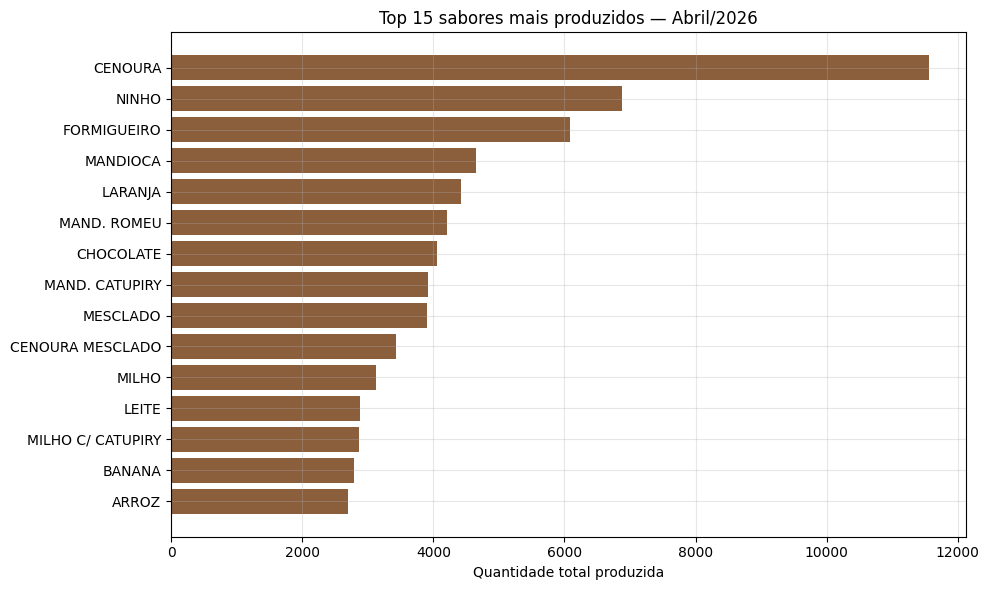

In [17]:
top_sabores = prod.groupby('SABOR')['QUANTIDADE'].sum().sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_sabores.index[::-1], top_sabores.values[::-1], color='#8B5E3C')
plt.title('Top 15 sabores mais produzidos — Abril/2026')
plt.xlabel('Quantidade total produzida')
plt.tight_layout()
plt.show()

### 8.2. Produção total por loja

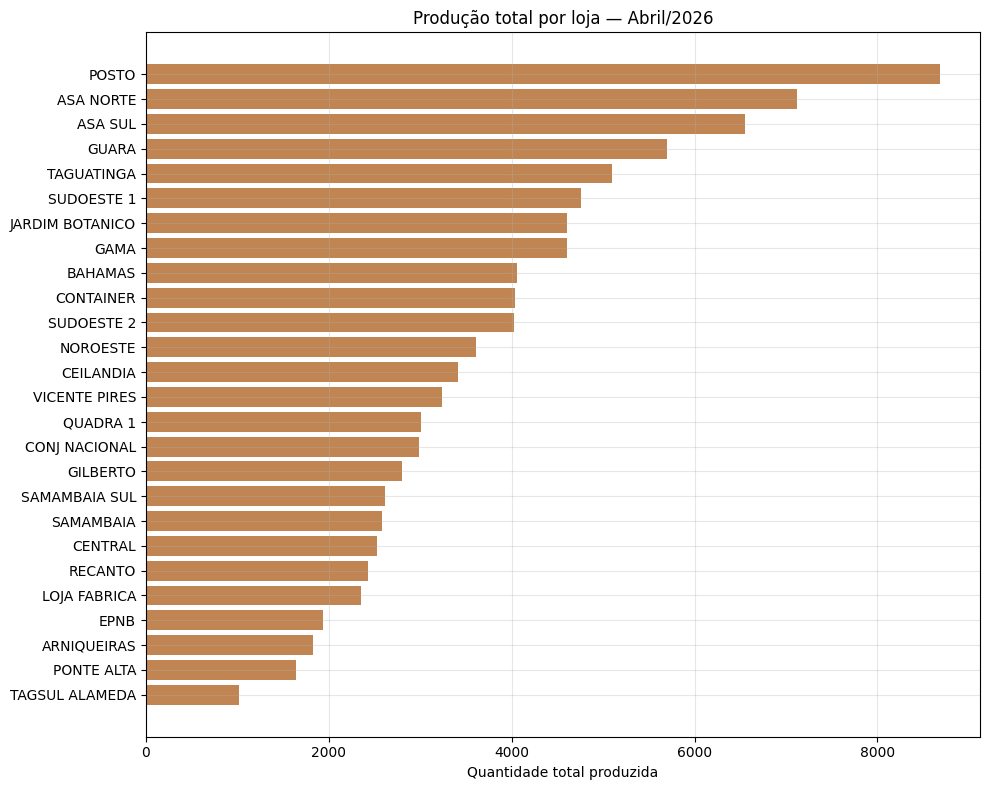

In [18]:
prod_loja = prod.groupby('LOJA')['QUANTIDADE'].sum().sort_values()

plt.figure(figsize=(10, 8))
plt.barh(prod_loja.index, prod_loja.values, color='#C08552')
plt.title('Produção total por loja — Abril/2026')
plt.xlabel('Quantidade total produzida')
plt.tight_layout()
plt.show()

### 8.3. Produção média em um dia típico de cada dia da semana

Como cada dia da semana ocorre um número diferente de vezes no mês, comparamos a **média da produção diária** por dia da semana (e não a soma), para uma comparação justa.

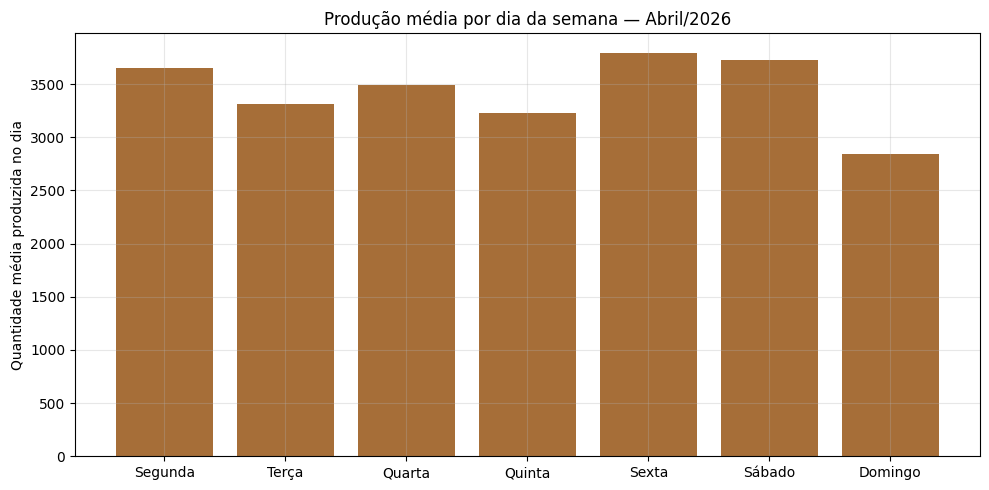

In [19]:
# Produção total por data e, depois, média por dia da semana
total_por_dia = prod.groupby('DATA')['QUANTIDADE'].sum().reset_index()
total_por_dia['DIA_SEMANA'] = total_por_dia['DATA'].dt.weekday
nomes_dias = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo']
media_dow = total_por_dia.groupby('DIA_SEMANA')['QUANTIDADE'].mean()

plt.figure(figsize=(10, 5))
plt.bar([nomes_dias[i] for i in media_dow.index], media_dow.values, color='#A66E38')
plt.title('Produção média por dia da semana — Abril/2026')
plt.ylabel('Quantidade média produzida no dia')
plt.tight_layout()
plt.show()

### 8.4. Distribuição da quantidade produzida

Mostramos a distribuição com e sem os zeros, para evidenciar a natureza "zero-inflada" dos dados.

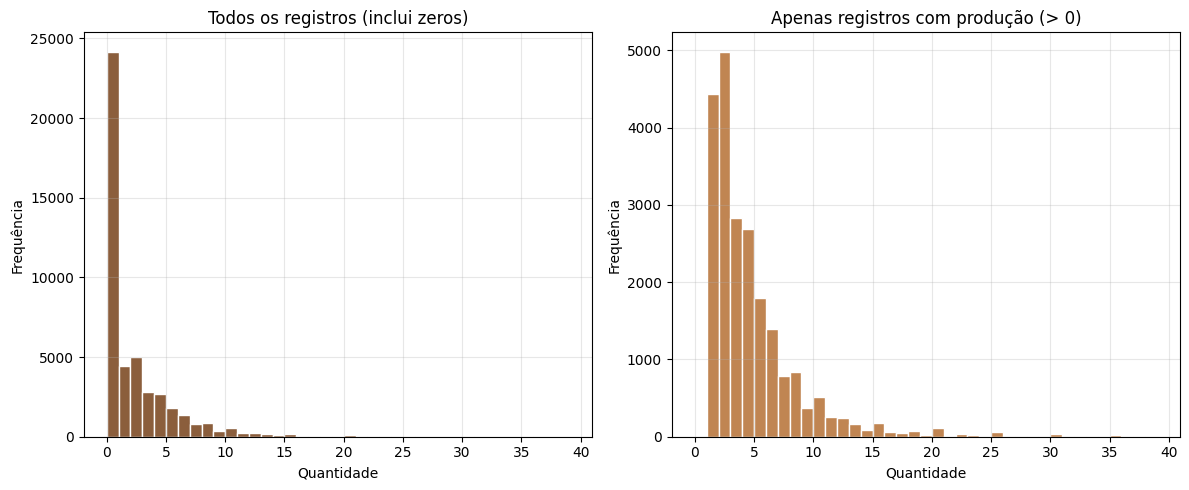

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(prod['QUANTIDADE'], bins=range(0, 40), color='#8B5E3C', edgecolor='white')
axes[0].set_title('Todos os registros (inclui zeros)')
axes[0].set_xlabel('Quantidade'); axes[0].set_ylabel('Frequência')

axes[1].hist(prod.loc[prod['QUANTIDADE'] > 0, 'QUANTIDADE'], bins=range(0, 40),
             color='#C08552', edgecolor='white')
axes[1].set_title('Apenas registros com produção (> 0)')
axes[1].set_xlabel('Quantidade'); axes[1].set_ylabel('Frequência')

plt.tight_layout()
plt.show()

### 8.5. Evolução da produção ao longo do mês

A linha do tempo ajuda a identificar tendências e quedas (ex.: domingos com produção mais baixa).

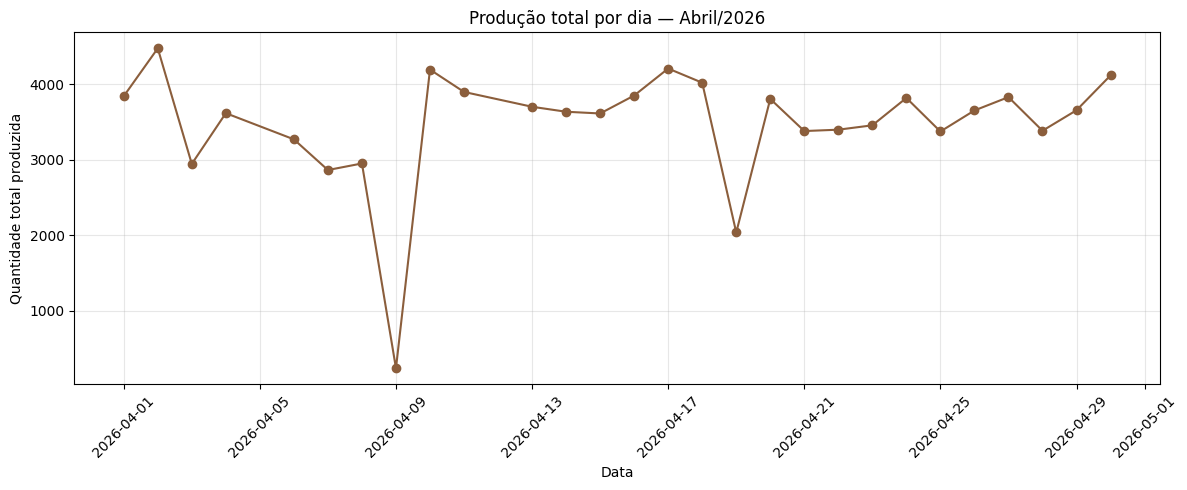

In [21]:
serie_dia = prod.groupby('DATA')['QUANTIDADE'].sum()

plt.figure(figsize=(12, 5))
plt.plot(serie_dia.index, serie_dia.values, marker='o', color='#8B5E3C')
plt.title('Produção total por dia — Abril/2026')
plt.ylabel('Quantidade total produzida')
plt.xlabel('Data')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 8.6. Faturamento líquido por loja

Ligando com a segunda base, vemos o faturamento líquido acumulado de cada loja no mês.

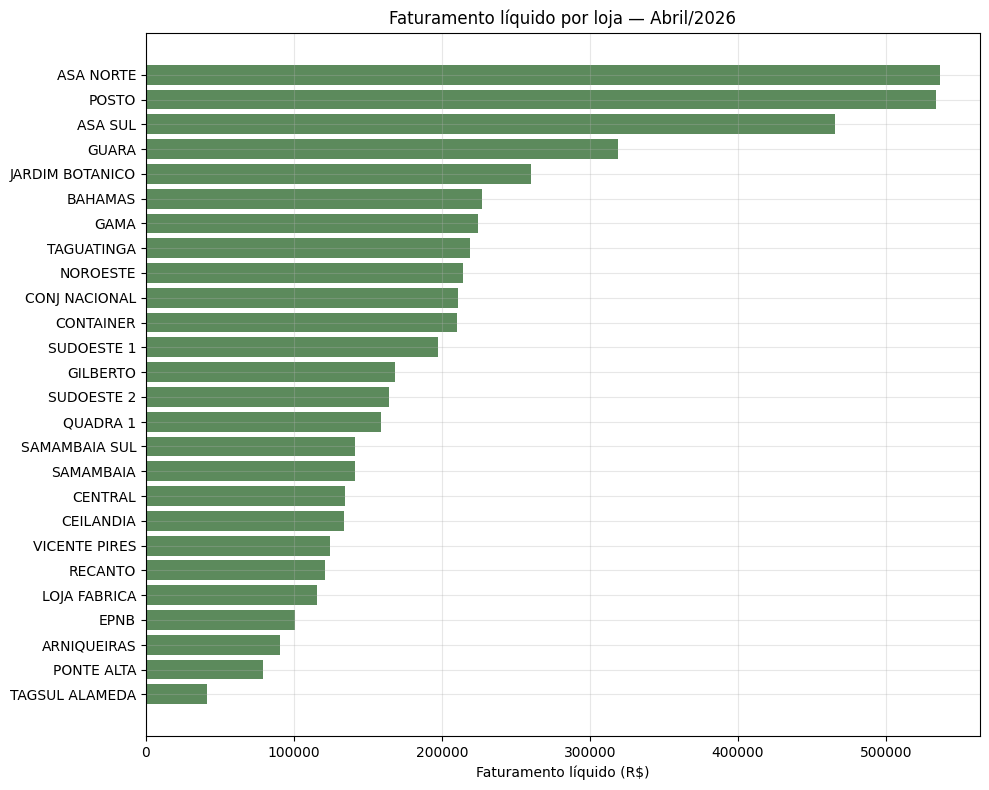

In [22]:
fat_loja = fat.groupby('LOJA_NOME')['FATURAMENTO LIQUIDO'].sum().sort_values()

plt.figure(figsize=(10, 8))
plt.barh(fat_loja.index, fat_loja.values, color='#5C8A5C')
plt.title('Faturamento líquido por loja — Abril/2026')
plt.xlabel('Faturamento líquido (R$)')
plt.tight_layout()
plt.show()

As visualizações revelam padrões claros: poucos sabores (liderados por CENOURA) concentram grande parte da produção; há forte variação de porte entre lojas; sexta e sábado são os dias de maior produção e domingo o menor; e a distribuição de quantidade é concentrada em valores baixos com alguns picos. Esses padrões justificam o uso de **loja**, **sabor** e **dia da semana** como variáveis preditoras na próxima etapa.

## 9. Integração das bases

As duas bases têm granularidades diferentes: produção é por *sabor × loja × dia* e faturamento é por *loja × dia*. Para integrá-las de forma coerente, **agregamos a produção ao nível de loja × dia** (somando as quantidades de todos os sabores) e então fazemos a junção com o faturamento pela chave comum `COD_LOJA` + `DATA`.

O objetivo é responder a uma pergunta de negócio: **lojas que produzem mais bolos num dia também faturam mais nesse dia?**

### 9.1. Agregação da produção por loja e dia

In [23]:
prod_diaria = prod.groupby(['COD_LOJA', 'DATA']).agg(
    QTD_PRODUZIDA=('QUANTIDADE', 'sum'),
    SABORES_PRODUZIDOS=('QUANTIDADE', lambda x: (x > 0).sum())
).reset_index()

print('Produção agregada (loja x dia):', prod_diaria.shape)
display(prod_diaria.head())

Produção agregada (loja x dia): (713, 4)


,COD_LOJA,DATA,QTD_PRODUZIDA,SABORES_PRODUZIDOS
0,0001,2026-04-01,270.0,43
1,0001,2026-04-02,317.0,41
2,0001,2026-04-03,199.0,39
3,0001,2026-04-04,183.0,34
4,0001,2026-04-06,155.0,41


### 9.2. Junção com o faturamento

Usamos junção interna (`inner`): permanecem apenas as combinações loja × dia presentes nas **duas** bases. Como a produção não tem registro em 2 dias (domingos 05 e 12), esses dias ficam naturalmente de fora desta análise integrada.

In [24]:
base_integrada = pd.merge(
    prod_diaria,
    fat[['COD_LOJA', 'DATA', 'LOJA_NOME', 'FATURAMENTO LIQUIDO', 'FATURAMENTO BRUTO']],
    on=['COD_LOJA', 'DATA'], how='inner'
)

print('Base integrada:', base_integrada.shape[0], 'registros |',
      base_integrada['COD_LOJA'].nunique(), 'lojas |',
      base_integrada['DATA'].nunique(), 'dias')
display(base_integrada.head())

Base integrada: 696 registros | 26 lojas | 28 dias


,COD_LOJA,DATA,QTD_PRODUZIDA,SABORES_PRODUZIDOS,LOJA_NOME,FATURAMENTO LIQUIDO,FATURAMENTO BRUTO
0,0001,2026-04-01,270.0,43,ASA SUL,18173.05,18578.6
1,0001,2026-04-02,317.0,41,ASA SUL,22852.63,23302.3
2,0001,2026-04-03,199.0,39,ASA SUL,9567.77,9638.6
3,0001,2026-04-04,183.0,34,ASA SUL,19691.16,20296.5
4,0001,2026-04-06,155.0,41,ASA SUL,14355.18,14935.7


### 9.3. Relação entre produção e faturamento

Correlação de Pearson (produção x faturamento líquido): 0.822


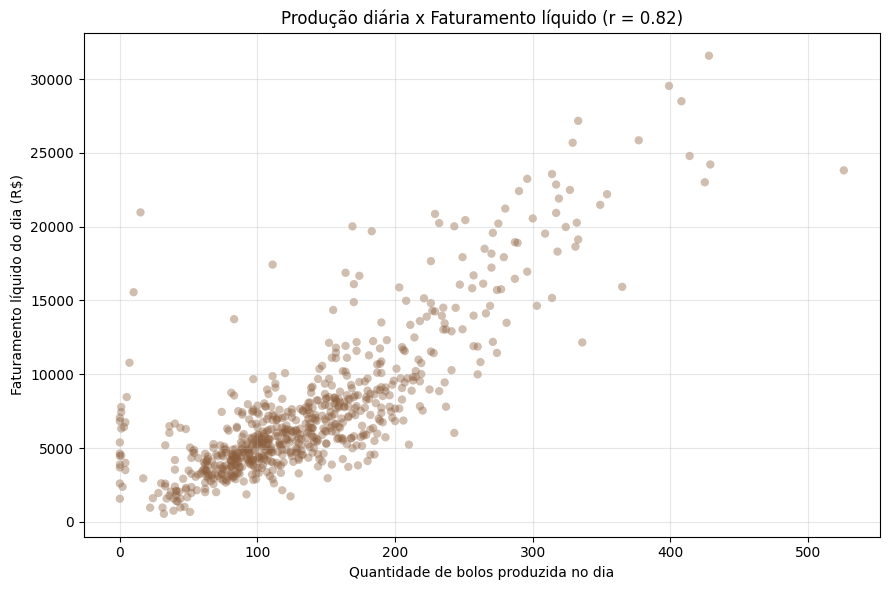

In [25]:
correlacao = base_integrada['QTD_PRODUZIDA'].corr(base_integrada['FATURAMENTO LIQUIDO'])
print(f'Correlação de Pearson (produção x faturamento líquido): {correlacao:.3f}')

plt.figure(figsize=(9, 6))
plt.scatter(base_integrada['QTD_PRODUZIDA'], base_integrada['FATURAMENTO LIQUIDO'],
            alpha=0.4, color='#8B5E3C', edgecolor='none')
plt.title(f'Produção diária x Faturamento líquido (r = {correlacao:.2f})')
plt.xlabel('Quantidade de bolos produzida no dia')
plt.ylabel('Faturamento líquido do dia (R$)')
plt.tight_layout()
plt.show()

**Interpretação:** a correlação de **0,82** indica uma relação positiva forte — dias de maior produção tendem a ser dias de maior faturamento, o que faz sentido operacionalmente e dá consistência às duas bases. A relação não é perfeita (r < 1) porque o faturamento também depende de fatores não capturados pela produção de bolos, como vendas de delivery, ticket médio e outros produtos. Essa base integrada poderia, em trabalhos futuros, alimentar um modelo que estima faturamento a partir do plano de produção.

## 10. Construção do modelo

**Problema:** estimar a **quantidade de produção** (`QUANTIDADE`) de um sabor para uma loja em um dia da semana. Como o alvo é numérico, trata-se de um problema de **regressão**.

**Modelo escolhido — `RandomForestRegressor`.** A escolha se justifica por:
- todas as variáveis preditoras são **categóricas** (loja, sabor, dia da semana), e árvores lidam naturalmente com interações entre categorias (ex.: "CENOURA na ASA SUL no sábado");
- não exige normalização nem premissas de linearidade;
- é robusto a outliers (temos picos de até 75 unidades);
- fornece a **importância das variáveis**, o que ajuda a interpretar o negócio.

**Variáveis preditoras:** `COD_LOJA`, `SABOR`, `DIA DA SEMANA`. **Alvo:** `QUANTIDADE`.

As categorias são transformadas com **One-Hot Encoding** dentro de um `Pipeline`, garantindo que o mesmo pré-processamento seja aplicado a treino e teste.

> **Nota honesta sobre o que o modelo aprende:** como cada combinação (loja, sabor, dia da semana) se repete várias vezes no mês, o modelo aprende essencialmente o **padrão histórico médio** de produção de cada combinação. Isso é um estimador de demanda legítimo. Justamente por isso, comparamos o modelo a um *baseline* simples (a média por grupo) para verificar se a Random Forest agrega valor de fato.

In [26]:
# Variáveis preditoras (X) e alvo (y)
X = prod[['COD_LOJA', 'SABOR', 'DIA DA SEMANA']].astype(str)
y = prod['QUANTIDADE']

# Pré-processamento + modelo em um único Pipeline
preprocessador = ColumnTransformer(
    transformers=[('categorias', OneHotEncoder(handle_unknown='ignore'),
                   ['COD_LOJA', 'SABOR', 'DIA DA SEMANA'])]
)

modelo = Pipeline(steps=[
    ('preprocessamento', preprocessador),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

print('Pipeline do modelo definido.')
print('Variáveis preditoras:', list(X.columns))

Pipeline do modelo definido.


Variáveis preditoras: ['COD_LOJA', 'SABOR', 'DIA DA SEMANA']


## 11. Treinamento

Separamos os dados em **80% para treino e 20% para teste** (`random_state=42` para reprodutibilidade). Treinamos a Random Forest e também construímos o *baseline*: a média de produção por grupo (loja, sabor, dia da semana) calculada **apenas no treino**, usando a média global para combinações nunca vistas.

In [27]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print('Treino:', X_treino.shape[0], 'registros | Teste:', X_teste.shape[0], 'registros')

# Treinamento da Random Forest
modelo.fit(X_treino, y_treino)
y_pred = modelo.predict(X_teste)
print('Random Forest treinada.')

# Baseline: média por grupo (calculada só no treino)
treino_aux = X_treino.copy()
treino_aux['y'] = y_treino.values
media_por_grupo = treino_aux.groupby(['COD_LOJA', 'SABOR', 'DIA DA SEMANA'])['y'].mean()
media_global = y_treino.mean()

chaves_teste = list(zip(X_teste['COD_LOJA'], X_teste['SABOR'], X_teste['DIA DA SEMANA']))
y_pred_baseline = np.array([media_por_grupo.get(k, media_global) for k in chaves_teste])
print('Baseline calculado.')

Treino: 37076 registros | Teste: 9269 registros


Random Forest treinada.
Baseline calculado.


## 12. Avaliação

Avaliamos com três métricas: **MAE** (erro médio absoluto, em unidades de bolo — a mais intuitiva), **RMSE** (penaliza mais erros grandes) e **R²** (proporção da variância explicada).

In [28]:
def avaliar(y_real, y_estimado):
    return {
        'MAE': mean_absolute_error(y_real, y_estimado),
        'RMSE': np.sqrt(mean_squared_error(y_real, y_estimado)),
        'R²': r2_score(y_real, y_estimado)
    }

resultados = pd.DataFrame({
    'Random Forest': avaliar(y_teste, y_pred),
    'Baseline (média por grupo)': avaliar(y_teste, y_pred_baseline)
}).T.round(3)

display(resultados)

,MAE,RMSE,R²
Random Forest,0.904,2.008,0.723
Baseline (média por grupo),0.985,2.141,0.685


A Random Forest supera o baseline em todas as métricas — ou seja, ela aprende algo além da simples média por grupo (consegue generalizar combinações pouco frequentes a partir de padrões parciais de loja, sabor e dia). O **MAE de ~0,9** significa que, em média, o modelo erra menos de **1 bolo** por previsão.

### 12.1. Importância das variáveis

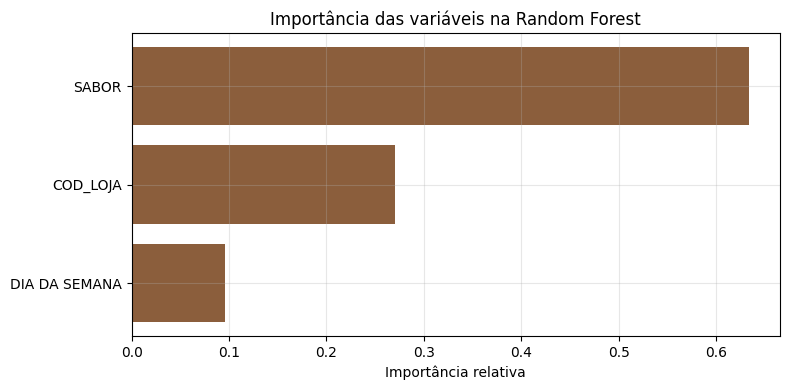

SABOR            0.634
COD_LOJA         0.270
DIA DA SEMANA    0.096
dtype: float64


In [29]:
# Importância agregada por variável original (somando as dummies de cada uma)
ohe = modelo.named_steps['preprocessamento'].named_transformers_['categorias']
nomes_dummies = ohe.get_feature_names_out(['COD_LOJA', 'SABOR', 'DIA DA SEMANA'])
importancias = modelo.named_steps['regressor'].feature_importances_

agg = {'COD_LOJA': 0.0, 'SABOR': 0.0, 'DIA DA SEMANA': 0.0}
for nome, imp in zip(nomes_dummies, importancias):
    for var in agg:
        if nome.startswith(var):
            agg[var] += imp
            break

imp_series = pd.Series(agg).sort_values()
plt.figure(figsize=(8, 4))
plt.barh(imp_series.index, imp_series.values, color='#8B5E3C')
plt.title('Importância das variáveis na Random Forest')
plt.xlabel('Importância relativa')
plt.tight_layout()
plt.show()

print(imp_series.sort_values(ascending=False).round(3))

O **sabor** é, de longe, o principal determinante da quantidade produzida (~63%), seguido pela **loja** (~27%) e pelo **dia da semana** (~10%). Faz sentido: sabores campeões como CENOURA são produzidos em volume muito maior, independentemente da loja.

### 12.2. Produção real x prevista

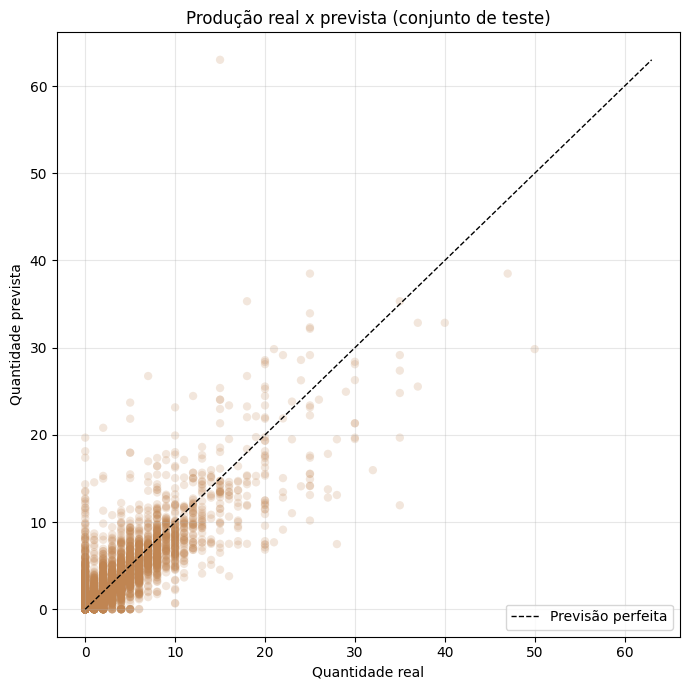

In [30]:
plt.figure(figsize=(7, 7))
plt.scatter(y_teste, y_pred, alpha=0.2, color='#C08552', edgecolor='none')
lim = max(y_teste.max(), y_pred.max())
plt.plot([0, lim], [0, lim], '--', color='black', linewidth=1, label='Previsão perfeita')
plt.title('Produção real x prevista (conjunto de teste)')
plt.xlabel('Quantidade real')
plt.ylabel('Quantidade prevista')
plt.legend()
plt.tight_layout()
plt.show()

## 13. Exemplo de utilização do modelo

Demonstramos o modelo em uso: informamos algumas combinações de loja, sabor e dia da semana e obtemos a quantidade estimada de produção — exatamente o tipo de apoio que o setor de PCP usaria para planejar a fábrica.

In [31]:
exemplos = pd.DataFrame({
    'COD_LOJA':      ['0001', '1001', '0007', '0004'],
    'SABOR':         ['CENOURA', 'CHOCOLATE', 'NINHO', 'FORMIGUEIRO'],
    'DIA DA SEMANA': ['sexta-feira', 'domingo', 'sábado', 'segunda-feira']
})

exemplos['QTD_PREVISTA'] = modelo.predict(exemplos).round(1)
exemplos['LOJA'] = exemplos['COD_LOJA'].map(codigo_para_nome)

display(exemplos[['LOJA', 'SABOR', 'DIA DA SEMANA', 'QTD_PREVISTA']])

,LOJA,SABOR,DIA DA SEMANA,QTD_PREVISTA
0,ASA SUL,CENOURA,sexta-feira,38.5
1,TAGUATINGA,CHOCOLATE,domingo,10.9
2,ASA NORTE,NINHO,sábado,15.0
3,BAHAMAS,FORMIGUEIRO,segunda-feira,8.5


O modelo responde de forma coerente com os padrões observados na análise exploratória: sabores e lojas de maior volume recebem estimativas mais altas. Em produção real, essa estimativa serviria como **ponto de partida** para o planejamento, sempre ajustada por fatores externos (feriados, datas comemorativas, promoções) que não estão nesta base.

## 14. Conclusão

Este projeto percorreu um fluxo completo de Ciência de Dados sobre dados **reais** da rede Bolos do Flávio, referentes a abril de 2026, utilizando exclusivamente as tecnologias da disciplina (Python, Pandas, NumPy, Matplotlib e Scikit-Learn).

**O que foi feito:**
- Importação e **limpeza** de duas bases com formatos e granularidades diferentes (produção: 46.345 registros; faturamento: 720 registros), incluindo conversão de tipos, tratamento de valores negativos, padronização de nomes de loja e criação de uma chave comum para integração.
- **Análise exploratória** e **estatísticas descritivas**, evidenciando que foram produzidos **97.231 bolos** no mês, que ~52% dos registros são de produção zero, e que poucos sabores (liderados pela CENOURA) concentram o volume.
- **Seis visualizações** em Matplotlib revelando padrões por sabor, loja, dia da semana e ao longo do mês.
- **Integração das bases**, mostrando uma correlação **positiva forte (r = 0,82)** entre a produção diária e o faturamento líquido.
- Um modelo de **regressão (Random Forest)** para estimar a quantidade de produção por loja, sabor e dia da semana.

**Principais resultados do modelo:** a Random Forest obteve **MAE ≈ 0,9** (erra, em média, menos de um bolo por previsão), **RMSE ≈ 2,0** e **R² ≈ 0,72**, superando um baseline de média por grupo. A variável mais influente foi o **sabor** (~63%), seguido de **loja** (~27%) e **dia da semana** (~10%).

**Limitações:**
- Os dados cobrem **um único mês**, o que limita a captura de sazonalidade de longo prazo.
- O modelo aprende o **padrão histórico médio** de cada combinação; não incorpora fatores externos (feriados, datas comemorativas, promoções, clima).
- O caráter **zero-inflado** do alvo limita o teto das métricas de regressão.

**Trabalhos futuros:**
- Incorporar mais meses de histórico e variáveis externas (calendário de feriados, eventos).
- Testar uma modelagem em duas etapas (primeiro "vai produzir?", depois "quanto?") para lidar melhor com os zeros.
- Usar a base integrada para estimar **faturamento** a partir do plano de produção, apoiando diretamente o planejamento do PCP.

O projeto demonstra que técnicas acessíveis de Ciência de Dados, aplicadas a dados reais de uma empresa, já produzem um instrumento útil e interpretável de apoio à decisão.

---
*Universidade Católica de Brasília — Curso de Ciência da Computação — Disciplina Novas Tecnologias.*